# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [241]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [242]:
df = pd.read_csv('House_Rent_Dataset.csv', sep=None, engine='python')
df.shape

(4746, 12)

In [243]:
df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [244]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [245]:
#1
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

In [246]:
#2
stats = df[['BHK', 'Rent', 'Size', 'Bathroom']].describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [247]:
#3
df_clean = df[df['Rent'].notna()].copy()

fig = px.histogram(
    df_clean,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (орендна плата)',
    labels={'Rent': 'Орендна плата', 'count': 'Кількість житлових приміщень'}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

In [248]:
df_clean['log_target'] = np.log1p(df_clean['Rent'])
fig = px.histogram(
    df_clean,
    x='log_target',
    nbins=100,
    title='Розподіл цільової змінної (орендна плата)',
    labels={'log_target': 'log Орендна плата', 'count': 'Кількість житлових приміщень'}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

In [249]:
#4
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

removed = len(df) - len(df_clean)

print(f"Видалено викидів: {removed}")

Видалено викидів: 520


In [250]:
#5
cat_cols = df_clean.select_dtypes(include=['object']).columns
df_clean[cat_cols].nunique()

Posted On              80
Floor                 340
Area Type               3
Area Locality        1997
City                    6
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [251]:
#1
metrics_df = df_clean[['BHK', 'Rent', 'Size', 'Bathroom']].dropna()

correlation_matrix = metrics_df.corr()

correlation_matrix

,BHK,Rent,Size,Bathroom
BHK,1.000000,0.401268,0.698453,0.747918
Rent,0.401268,1.000000,0.393605,0.506528
Size,0.698453,0.393605,1.000000,0.680607
Bathroom,0.747918,0.506528,0.680607,1.000000


In [252]:
#2
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між метриками взаємодії',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

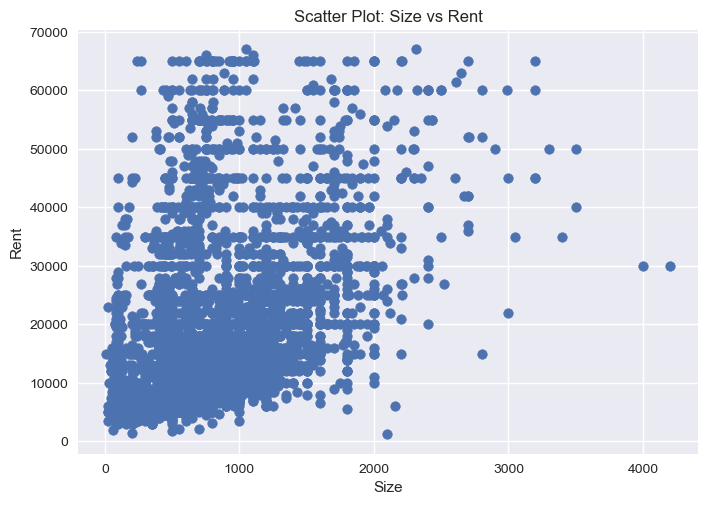

In [253]:
#3
import matplotlib.pyplot as plt

plt.scatter(df_clean['Size'], df_clean['Rent'])
plt.xlabel('Size')
plt.ylabel('Rent')
plt.title('Scatter Plot: Size vs Rent')
plt.show()

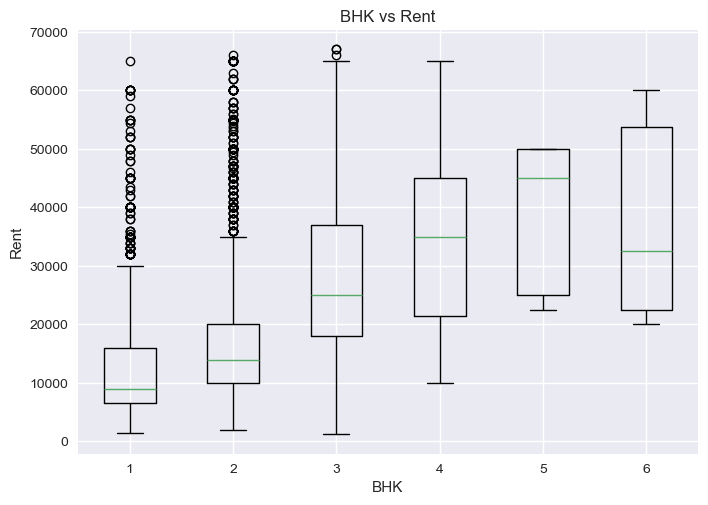

In [254]:
#4
import matplotlib.pyplot as plt

bhk_values = sorted(df_clean['BHK'].unique())
data = [df_clean[df_clean['BHK'] == bhk]['Rent'] for bhk in bhk_values]

plt.boxplot(data, tick_labels=bhk_values)

plt.xlabel('BHK')
plt.ylabel('Rent')
plt.title('BHK vs Rent')

plt.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [255]:
#1
city_dummies = pd.get_dummies(df_clean['City'], prefix='City')
city_dummies.head().astype(int)
df_clean = pd.concat([df_clean, city_dummies], axis=1)

In [256]:
area_type_dummies = pd.get_dummies(df_clean['Area Type'], prefix='Area Type')
area_type_dummies.head().astype(int)
df_clean = pd.concat([df_clean, area_type_dummies], axis=1)

In [257]:
furnishing_status_dummies = pd.get_dummies(df_clean['Furnishing Status'], prefix='Furnishing Status')
furnishing_status_dummies.head().astype(int)
df_clean = pd.concat([df_clean, furnishing_status_dummies], axis=1)

In [258]:
tenant_preferred_dummies = pd.get_dummies(df_clean['Tenant Preferred'], prefix='Tenant Preferred')
tenant_preferred_dummies.head().astype(int)
df_clean = pd.concat([df_clean, tenant_preferred_dummies], axis=1)

In [259]:
#2 Тут ми створюємо ознаку, яка показує, скільки днів розміщене оголошення про оренду житла. 
# За допомогою неї ми можемо побачити оголошення, які вже довго висять, що може означати, що 
# певне житло не орендують через високу ціну або погану якість приміщення.
from datetime import datetime

today = datetime.now()

df_clean['days'] = df_clean['Posted On'].apply(lambda x: (today - datetime.strptime(x, "%Y-%m-%d")).days)

df_clean['days']

0       1446
1       1451
2       1448
3       1399
4       1455
        ... 
4741    1446
4742    1449
4743    1393
4744    1397
4745    1460
Name: days, Length: 4226, dtype: int64

In [260]:
#3
corr_features = ['days', 'BHK', 'Size']
features = corr_features + area_type_dummies.columns.tolist() + city_dummies.columns.tolist() + tenant_preferred_dummies.columns.tolist() + furnishing_status_dummies.columns.tolist()

In [261]:
#4
X = df_clean[features]  # Ознаки
y = df_clean['Rent']  # Цільова змінна
print(f"\nРозмір X (ознак): {X.shape}")
print(f"Розмір y (цілі): {y.shape}")


Розмір X (ознак): (4226, 18)
Розмір y (цілі): (4226,)


In [262]:
#5
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [263]:
#1
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.2,  
    random_state=42  
)

In [264]:
#2
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [265]:
#3
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [266]:
#4
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

days: -779.50
BHK: 3559.05
Size: 5012.32
Area Type_Built Area: 22.94
Area Type_Carpet Area: 715.50
Area Type_Super Area: -716.42
City_Bangalore: -1027.46
City_Chennai: -1617.23
City_Delhi: 357.21
City_Hyderabad: -2075.51
City_Kolkata: -2238.59
City_Mumbai: 7158.69
Tenant Preferred_Bachelors: 430.93
Tenant Preferred_Bachelors/Family: -87.56
Tenant Preferred_Family: -432.82
Furnishing Status_Furnished: 1122.76
Furnishing Status_Semi-Furnished: 8.03
Furnishing Status_Unfurnished: -758.75

Зміщення (intercept): 19313.15


BNK і Size найбільше впливають на прогноз. Найбільша орендна плата в Мумбаї.

In [267]:
#5
y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Реальна орендна плата': y_test.values[:10],
    'Прогнозована орендна плата': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})
print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна орендна плата  Прогнозована орендна плата  Помилка
0                  22000                     34366.0 -12366.0
1                   5000                      3143.0   1857.0
2                  37000                     36378.0    622.0
3                   8000                      1716.0   6284.0
4                  15000                     14754.0    246.0
5                  20000                     26664.0  -6664.0
6                   8500                     13435.0  -4935.0
7                   7000                      3016.0   3984.0
8                   3000                     -1662.0   4662.0
9                   8000                      7400.0    600.0


Модель є не дуже точною.

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [268]:
#1
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print("="*50)
print(f"\nMAE: {mae:.2f} грошових одиниць")
print(f"RMSE: {rmse:.2f} грошових одиниць")
print(f"R²: {r2:.3f}")

mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print("="*50)
print(f"\nMAE: {mae:.2f} грошових одиниць")
print(f"RMSE: {rmse:.2f} грошових одиниць")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: 5977.08 грошових одиниць
RMSE: 8313.87 грошових одиниць
R²: 0.640
МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: 6006.22 грошових одиниць
RMSE: 8301.45 грошових одиниць
R²: 0.639


In [269]:
np.mean(y_train)

np.float64(19349.54852071006)

In [270]:
#2
R²: 0.640 і R²: 0.639 - це означає, що якість моделі трохи вище середньої.

SyntaxError: invalid character '²' (U+00B2) (2521941155.py, line 2)

3. Ознак перенавчання і недонавчання немає, бо MAE менше за середнє значення цільової змінної, а R2 на test і train майже однакові.

In [ ]:
#4 
# Візуалізація: реальні vs прогнозовані значення
fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальні vs Прогнозовані лайки (тестова вибірка)',
    labels={'x': 'Реальна орендна плата', 'y': 'Прогнозована орендна плата'},
    opacity=0.6
)

# Додаємо ідеальну лінію (де прогноз = реальність)
max_val = max(y_test.max(), y_test_pred.max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(height=500)
fig.show()

На графіку видно, що модель якісна.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [ ]:
#1
residuals = y_test - y_test_pred

In [ ]:
#2
fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig.update_layout(height=400)
fig.show()

In [ ]:
#3
# Scatter plot: помилки vs прогнозовані значення
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованих значень',
    labels={'x': 'Прогнозована орендна плата', 'y': 'Помилка'},
    opacity=0.5
)

# Додаємо горизонтальну лінію на 0
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")

fig.update_layout(height=400)
fig.show()

Помилка трохи росте з ростом прогнозованого значення.

In [ ]:
#4
# Знаходимо житло з найбільшими помилками
errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred,
    'error': np.abs(residuals)
})

# Топ-5 найбільших помилок
top_errors = errors_df.nlargest(5, 'error')
print("Житло з найбільшими помилками прогнозування:")
print(top_errors)

Житло з найбільшими помилками прогнозування:
       real     predicted         error
3520  65000  27647.923349  37352.076651
852    8000  39331.355502  31331.355502
549    8000  38058.004061  30058.004061
2658  60000  31426.017915  28573.982085
4374  57000  28857.742573  28142.257427


In [271]:
#5
result = (
    pd.concat([
        pd.DataFrame({'error': np.abs(residuals), 'BHK': X_test['BHK']}),
        city_dummies
    ], axis=1)
    .set_index('BHK')
)

analysis = (
    result[city_dummies.columns]
    .multiply(result['error'], axis=0)
    .groupby(level=0)
    .mean()
)

print(analysis)

           City_Bangalore  City_Chennai   City_Delhi  City_Hyderabad  \
BHK                                                                    
-1.287356      524.670042    528.788778   470.051509      600.825740   
 0.052966      917.211319    797.111795   958.872110      745.813047   
 1.393288     1614.025059   1643.111427  1667.245592     2401.916990   
 2.733610      691.886086   1013.073152  4282.951907     2659.822318   
 4.073931        0.000000      0.000000     0.000000     6956.237315   
 5.414253        0.000000   6822.400549     0.000000     1958.076329   

           City_Kolkata  City_Mumbai  
BHK                                   
-1.287356    634.090011  1955.617538  
 0.052966    553.988803  1437.631607  
 1.393288   1055.699191   473.176303  
 2.733610   2845.221999     0.000000  
 4.073931      0.000000     0.000000  
 5.414253      0.000000     0.000000  


Модель помиляється найбільше на житлі, яке здається в оренду у місті Hyderabad і має більше трьох кімнат.

6. Для покращення якості моделі можна виконати feature engineering (можна з колонки Floor дістати числове значення поверха і числове значення кількості поверхів у будівлі, використати ці дані як додаткові ознаки; також по колонці Area Locality ми можемо дістати з інтернету дані про район (ціна житла, кримінальний рейтинг) і також використати їх як додаткові ознаки).